# Test Infomap
Here I'll try to implement a function to compute the Infomap description length, tested with the previously created Test networks!

Side note: [This](https://python.igraph.org/en/latest/tutorials/cluster_contraction.html) might be useful!


To Do:
- 'Smart' Teleportation scheme (as opposed to uniform)
- proper comparison to both igraph and other implementations

In [20]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings


from map_equation import (
    compute_description_length,
    compute_description_length_uniform,
)

# the helper functions are located in the src folder
#import sys
#sys.path.append("..")

import infomap_funcss as inf

In [21]:
from infomap import Infomap

def L_official_on_partition(g, partition):
    """Evaluate the official infomap package's codelength on a given partition."""
    im = Infomap(directed=g.is_directed(), two_level=True, silent=True)
    weighted = g.is_weighted()
    for e in g.es:
        im.add_link(e.source, e.target, e["weight"] if weighted else 1.0)
    im.run(initial_partition={nid: mod for nid, mod in enumerate(partition)})
    return im.codelength

In [22]:
# little helper for plotting purposes
# might make a a seperate python file for all utility functions later on
def visual_community_colors(g: ig.Graph):
    if "community" in g.vertex_attributes():
        c = max(g.vs["community"]) + 1 
        palette = ig.RainbowPalette(n=c)
    visual_style = {}
    visual_style["vertex_size"] = 20
    visual_style["vertex_color"] = [palette.get(i) for i in g.vs["community"]] if "community" in g.vertex_attributes() else "lightblue"
    visual_style["layout"] = g.layout('fr')
    visual_style["bbox"] = (400, 400)
    visual_style["margin"] = 20
    visual_style["vertex_label_angle"] = 90
    visual_style["vertex_label_dist"] = 2.
    visual_style["edge_width"] = [1+w * 5 for w in g.es["weight"]] if "weight" in g.edge_attributes() else 1
    visual_style["edge_color"] = "rgba(1,1,1,0.7)" if "weight" in g.edge_attributes() else "rgba(1,1,1,1)"
    return visual_style

In [23]:
# load test networks
g1 = ig.Graph.Read_GraphML("C:/Users/savin/ITI/unweighted_undirected.graphml")
ig.plot(g1, **visual_community_colors(g1))

AttributeError: Plotting not available; please install pycairo or cairocffi

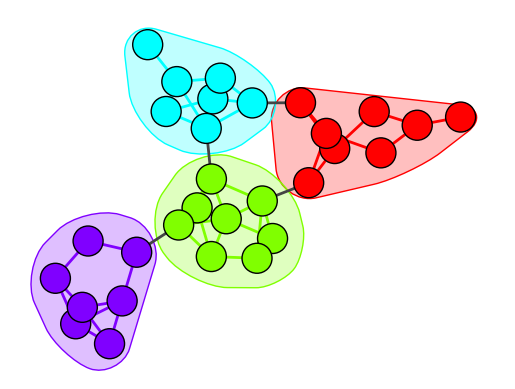

In [24]:
communities = ig.VertexClustering.FromAttribute(g1, "community")

num_communities = len(communities)
palette = ig.RainbowPalette(n=num_communities)
for i, community in enumerate(communities):
    g1.vs[community]["color"] = i   # Remove this to keep the original colors
    community_edges = g1.es.select(_within=community)
    community_edges["color"] = i

fig, ax = plt.subplots()
ig.plot(
    communities,
    target=ax,
    mark_groups=True,
    palette=palette
)
#plt.show()

## Computing the description length
For the given test network with the given partitioning into communities, let's compute the description length as defined by the Map equation!
... which means we need the node visit frequencies etc. So, for our 4 cases:
- *unweighted, undirected*: node visit frequency = relative node degree? = degree(node)/2*|E| ??
- *weighted, undirected*: node visit frequency = relative weight of links connected to the node
$$ = \frac{w(\text{links connected to node})}{2\cdot w(\text{all links in network})}
$$
With directed networks, things get more complicated - need teleportation probability $\tau$, estimate ergodic node visit frequencies via power iteration method (see PageRank algorithm)

Let's test everything with the test networks we created previously:

In [25]:
g1 = ig.Graph.Read_GraphML("C:/Users/savin/ITI/unweighted_undirected.graphml")
communities1 = g1.community_infomap()
partition = communities1.membership

L_uniform    = inf.compute_description_length(g1, partition, teleportation="uniform")
L_nonuniform = inf.compute_description_length(g1, partition, teleportation="nonuniform")

print(f"custom uniform:    {L_uniform:.4f}")
print(f"custom nonuniform: {L_nonuniform:.4f}")
print(f"igraph:            {communities1.codelength:.4f}")

custom uniform:    3.4016
custom nonuniform: 3.4016
igraph:            3.4016


In [26]:
g2 = ig.Graph.Read_GraphML("C:/Users/savin/ITI/weighted_undirected.graphml")
communities2 = g2.community_infomap(edge_weights="weight")
partition = communities2.membership

L_uniform    = inf.compute_description_length(g2, partition, teleportation="uniform")
L_nonuniform = inf.compute_description_length(g2, partition, teleportation="nonuniform")

print(f"custom uniform:    {L_uniform:.4f}")
print(f"custom nonuniform: {L_nonuniform:.4f}")
print(f"igraph:            {communities2.codelength:.4f}")

custom uniform:    3.3367
custom nonuniform: 3.3367
igraph:            3.3367


In [27]:
g3 = ig.Graph.Read_GraphML("C:/Users/savin/ITI/unweighted_directed.graphml")
communities3 = g3.community_infomap()
partition = communities3.membership

L_uniform    = inf.compute_description_length(g3, partition, teleportation="uniform")
L_nonuniform = inf.compute_description_length(g3, partition, teleportation="nonuniform")
L_official   = L_official_on_partition(g3, partition)

print(f"custom uniform:    {L_uniform:.4f}")
print(f"custom nonuniform: {L_nonuniform:.4f}")
print(f"igraph:            {communities3.codelength:.4f}")
print(f"official infomap:  {L_official:.4f}   (on same partition)")

custom uniform:    3.7540
custom nonuniform: 3.0894
igraph:            3.5158
official infomap:  3.1215   (on same partition)


In [28]:
g4 = ig.Graph.Read_GraphML("C:/Users/savin/ITI/weighted_directed.graphml")
communities4 = g4.community_infomap(edge_weights="weight")
partition = communities4.membership

L_uniform    = inf.compute_description_length(g4, partition, teleportation="uniform")
L_nonuniform = inf.compute_description_length(g4, partition, teleportation="nonuniform")
L_official   = L_official_on_partition(g4, partition)

print(f"custom uniform:    {L_uniform:.4f}")
print(f"custom nonuniform: {L_nonuniform:.4f}")
print(f"igraph:            {communities4.codelength:.4f}")
print(f"official infomap:  {L_official:.4f}   (on same partition)")

custom uniform:    3.4955
custom nonuniform: 2.7365
igraph:            3.3920
official infomap:  2.7130   (on same partition)


As you can see, the results for the directed networks don't really match. This may be because igraph is actually using a smart teleportation scheme that takes the node strength into account instead of just uniformly teleporting. I'll read up on that a bit more and check.

For performing the greedy search later, it is useful to have a function that updates the description length if 2 communities are merged. Since not all terms need to be recomputed, it is more efficient to do an update than to recompute from scratch. For the simulated annealing later, it might be useful to also implement an update function for the movement of a node from one community to another, but that's a ✨future problem✨.

### Testing the update function for merging:

undirected, unweighted:

In [29]:
comm1 = 1
comm2 = 2
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities1.membership)
communities_new = np.where(communities_old != comm2, communities_old, comm1)
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g1, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g1, communities_new) # recompute from scratch
L_merged_2 = inf.update_merge_description_length(g1, communities_old, p_old, p_mod_old, exit_weights, comm1, comm2) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.8175277537602357
updated:  3.8175277537602352


weighted, undirected:

In [30]:
comm1 = 1
comm2 = 2
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities2.membership)
communities_new = np.where(communities_old != comm2, communities_old, comm1)
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g2, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g2, communities_new) # recompute from scratch
L_merged_2 = inf.update_merge_description_length(g2, communities_old, p_old, p_mod_old, exit_weights, comm1, comm2) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.6708378661066496
updated:  3.6708378661066496


unweighted, directed:

In [31]:
comm1 = 1
comm2 = 2
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities3.membership)
communities_new = np.where(communities_old != comm2, communities_old, comm1)
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g3, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g3, communities_new) # recompute from scratch
L_merged_2 = inf.update_merge_description_length(g3, communities_old, p_old, p_mod_old, exit_weights, comm1, comm2) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.9670246859475
updated:  3.9670246859475


weighted, directed:

In [32]:
comm1 = 1
comm2 = 2
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities4.membership)
communities_new = np.where(communities_old != comm2, communities_old, comm1)
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g4, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g4, communities_new) # recompute from scratch
L_merged_2 = inf.update_merge_description_length(g4, communities_old, p_old, p_mod_old, exit_weights, comm1, comm2) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.687025957299013
updated:  3.687025957299013


Comparing the time of updating vs recomputing:

In [33]:
%timeit -n100 -r50 L_merged_1 = inf.compute_description_length(g4, communities_new) # recompute from scratch

6.38 ms ± 631 µs per loop (mean ± std. dev. of 50 runs, 100 loops each)


In [34]:
%timeit -n100 -r50 L_merged_2 = inf.update_merge_description_length(g4, communities_old, p_old, p_mod_old, exit_weights, comm1, comm2) # update existing

407 µs ± 109 µs per loop (mean ± std. dev. of 50 runs, 100 loops each)


Yep, updating sure is faster!

### Updating for single-node movement
... so turns out I may have implemented the wrong kind of update, and instead of merging it might be way more useful to write an update in case of one node being moved from one community to another. 

Checking the exit flow update function:

In [35]:
# Benchmarking exit flow computation
# check if it's faster to update the exit flow with update_exit_flow()
# or just recompute from scratch with compute_exit_flow

# build a directed test graph
g_test = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=True, weighted=True)
communities = g_test.vs["community"]

p = inf.pagerank(np.array(g_test.get_adjacency(attribute="weight").data), tau=0.15)
exit_flow = inf.compute_exit_flow(g_test, communities, p)

node = 2
comm_src = communities[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1

communities_new = communities.copy()
communities_new[node] = comm_trg
exit_flow_updated = inf.update_exit_flow(g_test, communities, p, exit_flow, node, comm_src, comm_trg)
exit_flow_recomputed = inf.compute_exit_flow(g_test, communities_new, p)

print("exit_flow_old:", exit_flow)
print("exit_flow_updated:", exit_flow_updated)
print("exit_flow_recomputed:", exit_flow_recomputed)
print("max difference:", np.max(np.abs(exit_flow_updated - exit_flow_recomputed)))

# simple timing benchmark
n_trials = 10000
t_update = timeit.timeit(lambda: inf.update_exit_flow(g_test, communities, p, exit_flow, node, comm_src, comm_trg), number=n_trials)
t_recompute = timeit.timeit(lambda: inf.compute_exit_flow(g_test, communities_new, p), number=n_trials)
print(f"update_exit_flow: {t_update:.6f}s for {n_trials} runs")
print(f"compute_exit_flow: {t_recompute:.6f}s for {n_trials} runs")

exit_flow_old: [0.03158477 0.03232051 0.02800751 0.03317248]
exit_flow_updated: [0.03517037 0.03657551 0.02800751 0.03317248]
exit_flow_recomputed: [0.03517037 0.03657551 0.02800751 0.03317248]
max difference: 1.3877787807814457e-17
update_exit_flow: 8.355746s for 10000 runs
compute_exit_flow: 7.038779s for 10000 runs


Testing the new exit weight update function:

In [36]:
# Benchmarking exit flow computation
# check if it's faster to update the exit flow with update_exit_flow()
# or just recompute from scratch with compute_exit_flow

# build a directed test graph
g_test = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=False, weighted=True)
communities = g_test.vs["community"]
exit_weights = inf.compute_exit_weights(g_test, communities)

node = 2
comm_src = communities[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1

communities_new = communities.copy()
communities_new[node] = comm_trg
exit_weights_updated = inf.update_exit_weights(g_test, communities, exit_weights, node, comm_src, comm_trg)
exit_weights_recomputed = inf.compute_exit_weights(g_test, communities_new)

print("exit_weights_old:", exit_weights)
print("exit_weights_updated:", exit_weights_updated)
print("exit_weights_recomputed:", exit_weights_recomputed)
print("max difference:", np.max(np.abs(exit_weights_updated - exit_weights_recomputed)))

# simple timing benchmark
n_trials = 10000
t_update = timeit.timeit(lambda: inf.update_exit_weights(g_test, communities, exit_weights, node, comm_src, comm_trg), number=n_trials)
t_recompute = timeit.timeit(lambda: inf.compute_exit_weights(g_test, communities_new), number=n_trials)
print(f"update_exit_weights: {t_update:.6f}s for {n_trials} runs")
print(f"compute_exit_weights: {t_recompute:.6f}s for {n_trials} runs")

exit_weights_old: [ 4.81266967  9.26687192  8.2697385  10.67626353]
exit_weights_updated: [ 9.94181013 14.39601238  8.2697385  10.67626353]
exit_weights_recomputed: [ 9.94181013 14.39601238  8.2697385  10.67626353]
max difference: 5.329070518200751e-15
update_exit_weights: 1.158815s for 10000 runs
compute_exit_weights: 3.628025s for 10000 runs


Testing the full update function for single-node moves on the test networks:

Undirected, unweighted:

In [37]:
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities1.membership)
node = 2
comm_src = communities_old[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g1, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g1, communities_new) # recompute from scratch
L_merged_2 = inf.update_node_move_description_length(g1, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.602281651664555
updated:  3.602281651664555


Undirected, weighted:

In [38]:

# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities2.membership)
node = 2
comm_src = communities_old[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g2, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g2, communities_new) # recompute from scratch
L_merged_2 = inf.update_node_move_description_length(g2, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.7017317618840218
updated:  3.701731761884022


Directed, unweighted:

In [39]:
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities3.membership)
node = 2
comm_src = communities_old[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g3, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g3, communities_new) # recompute from scratch
L_merged_2 = inf.update_node_move_description_length(g3, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.8747504622499367
updated:  3.8747504622499367


Directed, weighted:

In [40]:
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities4.membership)
node = 2
comm_src = communities[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights = inf.compute_description_length(g4, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = inf.compute_description_length(g4, communities_new) # recompute from scratch
L_merged_2 = inf.update_node_move_description_length(g4, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.4955100410485587
updated:  None


C:\Users\savin\ITI\infomap_funcss.py:681: UserWarning: Node already in target community 1! No change.
  warnings.warn(f"Node already in target community {comm_trg}! No change.")


In [41]:
%timeit -n100 -r50 L_merged_1 = inf.compute_description_length(g4, communities_new) # recompute from scratch

6.37 ms ± 615 µs per loop (mean ± std. dev. of 50 runs, 100 loops each)


In [42]:
%timeit -n100 -r50 L_merged_2 = inf.update_node_move_description_length(g4, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg) # update existing
 # update existing

The slowest run took 5.79 times longer than the fastest. This could mean that an intermediate result is being cached.
2.72 µs ± 1.26 µs per loop (mean ± std. dev. of 50 runs, 100 loops each)


Seems to be working and be much faster, neat!

## Finding partition with minimum description length
To be suitable for testing, let's remove the "ground truth" about community membership from the test network:

In [43]:
del g1.vs["community"] # remove community attribute for testing purposes    
ig.plot(g1, **visual_community_colors(g1))

AttributeError: Plotting not available; please install pycairo or cairocffi

In [ ]:
%timeit -r50 communities = g1.community_infomap()

In [ ]:
# testing igraphs infomap implementation
communities = g1.community_infomap()
print(communities.codelength)

In [ ]:
## num_communities = len(communities)
palette = ig.RainbowPalette(n=num_communities)
for i, community in enumerate(communities):
    g1.vs[community]["color"] = i
    community_edges = g1.es.select(_within=community)
    community_edges["color"] = i

fig, ax = plt.subplots()
ig.plot(
    communities,
    palette=palette,
    edge_width=1,
    target=ax,
    vertex_size=20,
)

# Create a custom color legend
legend_handles = []
for i in range(num_communities):
    handle = ax.scatter(
        [],
        [],
        s=100,
        facecolor=palette.get(i),
        edgecolor="k",
        label=i,
    )
    legend_handles.append(handle)
ax.legend(
    handles=legend_handles,
    title="Community:",
    bbox_to_anchor=(0, 1.0),
    bbox_transform=ax.transAxes,
)
plt.show()